### Leitura Inicial do ODBC

In [4]:
import pandas as pd
import warnings
from pathlib import Path

# Ignorar avisos para uma saída mais limpa
warnings.filterwarnings('ignore')

# ── Parâmetros de período da análise ──────────────────────────────────────────
# Modo: 'completo' (sem filtro) ou 'intervalo' (filtra por data inicial/final)
MODO_PERIODO = 'intervalo'

# Coluna de data usada no filtro: 'lancamento', 'ite_pagrec_vencimento' ou 'iterea_pagamento'
COLUNA_DATA_ANALISE = 'lancamento'

# Usado quando MODO_PERIODO = 'intervalo' (formato YYYY-MM-DD)
DATA_INICIO = '2026-01-01'
DATA_FIM = '2026-12-31'

print(f"Modo período: {MODO_PERIODO}")
if MODO_PERIODO == 'intervalo':
    print(f"Coluna data : {COLUNA_DATA_ANALISE}")
    print(f"Intervalo   : {DATA_INICIO} até {DATA_FIM}")

# Resolve o caminho do CSV de forma robusta (funciona no notebook e no terminal)
candidatos = [
    Path('02-Referencias/Meus_Dados/base.csv'),
    Path('../02-Referencias/Meus_Dados/base.csv'),
    Path('../../02-Referencias/Meus_Dados/base.csv'),
    Path('Cofre_Trabalho/02-Referencias/Meus_Dados/base.csv'),
]
csv_path = next((p for p in candidatos if p.exists()), None)

if csv_path is None:
    print('Arquivo não encontrado. Caminhos tentados:')
    for p in candidatos:
        print(f' - {p.resolve()}')
    df = None
else:
    print(f'Lendo arquivo: {csv_path.resolve()}')
    df = None
    tentativas = [
        {'sep': ';', 'encoding': 'latin-1'},
        {'sep': ',', 'encoding': 'latin-1'},
        {'sep': ';', 'encoding': 'utf-8'},
        {'sep': ',', 'encoding': 'utf-8'},
    ]

    for t in tentativas:
        try:
            df = pd.read_csv(csv_path, sep=t['sep'], encoding=t['encoding'])
            print(f"Leitura OK com sep='{t['sep']}' e encoding='{t['encoding']}'")
            break
        except Exception as e:
            print(f"Falha com sep='{t['sep']}' e encoding='{t['encoding']}': {e}")

# Exibir as primeiras linhas do DataFrame se carregado com sucesso
if df is not None:
    display(df.head())
else:
    print('Não foi possível carregar o CSV.')

Modo período: intervalo
Coluna data : lancamento
Intervalo   : 2026-01-01 até 2026-12-31
Lendo arquivo: C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Meus_Dados\base.csv
Leitura OK com sep=';' e encoding='latin-1'


,codcen,descen,codcdc,descdc,lancamento,ite_pagrec_vencimento,iterea_pagamento,iterea_valpago,documento,codigo_pessoa,nome,valor_plano,valor_centro,observacao,nota,cab_pagrec_id,valor_bruto,filial
0,2.2.4.2,RECEITA / SELETIVA / MARINGA / COMERCIAL,4.1.1,VENDAS DE SUCATAS,30/03/2026,2026-04-29,NAO PAGO,0,BOLV-89075,470.0,GV DO BRASIL INDUSTRIA E COMERCIO DE ACO LTDA,"54531,9","54531,9",CARREGAMENTO EFETUADO NO PATIO DE MARINGA,14003-1/55;65374-1/55,56095.0,"54531,9",G3S MARINGA
1,2.2.5.2,RECEITA / SELETIVA / PRESIDENTE PRUDENTE / COM...,4.2.1,ADIANTAMENTO CLIENTE SUCATA,##############################################...,1800-01-01,1800-01-01,10,SALDO ADT CLI,1090.0,JOAO APARECIDO HENRIQUES,10,10,MIGRADO MIGRADO,NaN,1865.0,10,G3S PRUDENTE
2,1.2.5.2,GERAL CONSOLIDADO / SELETIVA / PRESIDENTE PRUD...,6.3.1,ADIANTAMENTOS CONCEDIDOS,##############################################...,1800-01-01,1800-01-01,3995,SALDO ADT FOR,5987.0,ADRIANA PINZAM MARTINS - ME,-3995,-3995,MIGRADO MIGRADO,NaN,1866.0,3995,G3S PRUDENTE
3,1.2.5.2,GERAL CONSOLIDADO / SELETIVA / PRESIDENTE PRUD...,6.3.1,ADIANTAMENTOS CONCEDIDOS,##############################################...,1800-01-01,1800-01-01,5000,SALDO ADT FOR,19949.0,ALCIDES ESPIGAROLE,-5000,-5000,MIGRADO MIGRADO,NaN,1867.0,5000,G3S PRUDENTE
4,2.2.4.2,RECEITA / SELETIVA / MARINGA / COMERCIAL,4.1.1,VENDAS DE SUCATAS,30/03/2026,2026-04-29,NAO PAGO,0,BOLV-89076,470.0,GV DO BRASIL INDUSTRIA E COMERCIO DE ACO LTDA,"55301,4","55301,4",CARREGAMENTO EFETUADO NO PATIO DE MARINGA,102039-1/55;65375-1/55,56110.0,"55301,4",G3S MARINGA


In [5]:
# Obter informações gerais sobre o DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67455 entries, 0 to 67454
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   codcen                 67454 non-null  str    
 1   descen                 67454 non-null  str    
 2   codcdc                 67454 non-null  str    
 3   descdc                 67454 non-null  str    
 4   lancamento             67454 non-null  str    
 5   ite_pagrec_vencimento  67454 non-null  str    
 6   iterea_pagamento       67454 non-null  str    
 7   iterea_valpago         67455 non-null  str    
 8   documento              67454 non-null  str    
 9   codigo_pessoa          67454 non-null  float64
 10  nome                   67443 non-null  str    
 11  valor_plano            67454 non-null  str    
 12  valor_centro           67454 non-null  str    
 13  observacao             67454 non-null  str    
 14  nota                   53016 non-null  str    
 15  cab_pagrec_id

In [6]:
# Verificar valores nulos
df.isnull().sum()

codcen                       1
descen                       1
codcdc                       1
descdc                       1
lancamento                   1
ite_pagrec_vencimento        1
iterea_pagamento             1
iterea_valpago               0
documento                    1
codigo_pessoa                1
nome                        12
valor_plano                  1
valor_centro                 1
observacao                   1
nota                     14439
cab_pagrec_id                1
valor_bruto                  1
filial                       1
dtype: int64

### Limpeza e Tipagem dos Dados

Conversão das colunas financeiras (string → float), parsing de datas, criação da flag `pago` e extração da hierarquia do centro de custo.

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 1. Remover linha corrompida (lancamento NaN) ───────────────────────────────
df = df.dropna(subset=['lancamento']).copy()
print(f"Registros após remoção de linha corrompida: {len(df):,}")

# ── 2. Colunas financeiras: limpeza e conversão ────────────────────────────────
COLUNAS_FINANCEIRAS = ['valor_plano', 'valor_centro', 'valor_bruto', 'iterea_valpago']

for col in COLUNAS_FINANCEIRAS:
    antes = df[col].isna().sum()
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r'[R$\s]', '', regex=True)
        .str.replace('.', '', regex=False)   # remove separador de milhar BR
        .str.replace(',', '.', regex=False)  # converte decimal BR → EN
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
    depois = df[col].isna().sum()
    novos_nans = depois - antes
    print(f"  [{col}] Novos NaN após conversão: {novos_nans} (total NaN: {depois})")

# ── 3. Parsing de datas ────────────────────────────────────────────────────────
df['vencimento'] = pd.to_datetime(df['ite_pagrec_vencimento'], errors='coerce')
df['lancamento_dt'] = pd.to_datetime(df['lancamento'], format='%d/%m/%Y', errors='coerce')
pag_raw = df['iterea_pagamento'].astype(str).str.strip()
df['pagamento_dt'] = pd.to_datetime(pag_raw.mask(pag_raw.str.upper().eq('NAO PAGO')), errors='coerce')

# ── 4. Filtro de período (opcional) ───────────────────────────────────────────
if MODO_PERIODO == 'completo':
    print("\nFiltro de período: desativado (base completa).")
elif MODO_PERIODO == 'intervalo':
    coluna_map = {
        'lancamento': 'lancamento_dt',
        'ite_pagrec_vencimento': 'vencimento',
        'iterea_pagamento': 'pagamento_dt'
    }
    col_data = coluna_map.get(COLUNA_DATA_ANALISE)
    if col_data is None:
        raise ValueError("COLUNA_DATA_ANALISE inválida. Use: 'lancamento', 'ite_pagrec_vencimento' ou 'iterea_pagamento'.")

    dt_ini = pd.to_datetime(DATA_INICIO, errors='coerce')
    dt_fim = pd.to_datetime(DATA_FIM, errors='coerce')
    if pd.isna(dt_ini) or pd.isna(dt_fim):
        raise ValueError("DATA_INICIO e DATA_FIM devem estar no formato YYYY-MM-DD")
    if dt_ini > dt_fim:
        raise ValueError("DATA_INICIO não pode ser maior que DATA_FIM")

    antes = len(df)
    df = df[df[col_data].between(dt_ini, dt_fim, inclusive='both')].copy()
    print(f"\nFiltro de período aplicado em '{COLUNA_DATA_ANALISE}': {DATA_INICIO} até {DATA_FIM}")
    print(f"Registros após filtro de período: {len(df):,} (de {antes:,})")
else:
    raise ValueError("MODO_PERIODO inválido. Use: 'completo' ou 'intervalo'.")

# Flag de data válida: entre 2015-01-01 e 2029-12-31
DATA_MIN = pd.Timestamp('2015-01-01')
DATA_MAX = pd.Timestamp('2029-12-31')
df['data_valida'] = df['vencimento'].between(DATA_MIN, DATA_MAX)
n_invalidas = (~df['data_valida'] & df['vencimento'].notna()).sum()
print(f"\nDatas fora do intervalo esperado (2015–2029): {n_invalidas}")

# ── 5. Flag de pagamento ───────────────────────────────────────────────────────
df['pago'] = df['iterea_pagamento'].str.strip().str.upper() != 'NAO PAGO'
print(f"\nRegistros PAGOS:    {df['pago'].sum():,}")
print(f"Registros NAO PAGO: {(~df['pago']).sum():,}")

# ── 6. Extração da hierarquia do centro de custo ───────────────────────────────
partes_cc = df['descen'].str.split('/', expand=True).apply(lambda s: s.str.strip())
df['tipo_cc']    = partes_cc[0]
df['divisao_cc'] = partes_cc[1]
df['cidade_cc']  = partes_cc[2]
df['dept_cc']    = partes_cc[3]

# ── 7. Normalização de filial (G&S → G3S) ────────────────────────────────────
df['grupo_filial'] = df['filial'].str.replace('G&S', 'G3S', regex=False)

# ── 8. Grupo do Plano de Contas (primeiro dígito de codcdc) ──────────────────
df['grupo_pc'] = df['codcdc'].str.extract(r'^(\d+)')

print(f"\nShape final do DataFrame limpo: {df.shape}")
df.head(3)

Registros após remoção de linha corrompida: 67,454
  [valor_plano] Novos NaN após conversão: 0 (total NaN: 0)
  [valor_centro] Novos NaN após conversão: 0 (total NaN: 0)
  [valor_bruto] Novos NaN após conversão: 0 (total NaN: 0)
  [iterea_valpago] Novos NaN após conversão: 0 (total NaN: 0)

Filtro de período aplicado em 'lancamento': 2026-01-01 até 2026-12-31
Registros após filtro de período: 22,097 (de 67,454)

Datas fora do intervalo esperado (2015–2029): 0

Registros PAGOS:    19,579
Registros NAO PAGO: 2,518

Shape final do DataFrame limpo: (22097, 29)


,codcen,descen,codcdc,descdc,lancamento,ite_pagrec_vencimento,iterea_pagamento,iterea_valpago,documento,codigo_pessoa,...,lancamento_dt,pagamento_dt,data_valida,pago,tipo_cc,divisao_cc,cidade_cc,dept_cc,grupo_filial,grupo_pc
0,2.2.4.2,RECEITA / SELETIVA / MARINGA / COMERCIAL,4.1.1,VENDAS DE SUCATAS,30/03/2026,2026-04-29,NAO PAGO,0.0,BOLV-89075,470.0,...,2026-03-30,NaT,True,False,RECEITA,SELETIVA,MARINGA,COMERCIAL,G3S MARINGA,4
4,2.2.4.2,RECEITA / SELETIVA / MARINGA / COMERCIAL,4.1.1,VENDAS DE SUCATAS,30/03/2026,2026-04-29,NAO PAGO,0.0,BOLV-89076,470.0,...,2026-03-30,NaT,True,False,RECEITA,SELETIVA,MARINGA,COMERCIAL,G3S MARINGA,4
6,2.2.4.2,RECEITA / SELETIVA / MARINGA / COMERCIAL,4.1.1,VENDAS DE SUCATAS,30/03/2026,2026-04-29,NAO PAGO,0.0,BOLV-89078,470.0,...,2026-03-30,NaT,True,False,RECEITA,SELETIVA,MARINGA,COMERCIAL,G3S MARINGA,4


### KPIs Gerais

In [8]:
# Paleta corporativa
CORES = {
    'primario':    '#1B4F72',
    'secundario':  '#2E86C1',
    'destaque':    '#F39C12',
    'perigo':      '#C0392B',
    'sucesso':     '#1E8449',
    'neutro':      '#7F8C8D',
}

fmt_brl = lambda x, pos: f"R$ {x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')

total_bruto    = df['valor_bruto'].sum()
total_pago     = df.loc[df['pago'], 'valor_bruto'].sum()
total_em_aberto = df.loc[~df['pago'], 'valor_bruto'].sum()
n_filiais      = df['filial'].nunique()
n_categorias   = df['descdc'].nunique()
n_fornecedores = df['nome'].nunique()
ticket_medio   = df['valor_bruto'].mean()

kpis = {
    'Total de Lançamentos':       f"{len(df):,}",
    'Volume Bruto Total':         f"R$ {total_bruto:,.2f}",
    'Volume Pago':                f"R$ {total_pago:,.2f}",
    'Em Aberto (NAO PAGO)':       f"R$ {total_em_aberto:,.2f}",
    'Ticket Médio por Lançamento': f"R$ {ticket_medio:,.2f}",
    'Filiais':                    str(n_filiais),
    'Categorias (descdc)':        str(n_categorias),
    'Fornecedores/Clientes':      str(n_fornecedores),
}

print("=" * 55)
print("            PAINEL DE KPIs — MOVIMENTAÇÃO")
print("=" * 55)
for k, v in kpis.items():
    print(f"  {k:<35} {v:>18}")
print("=" * 55)

            PAINEL DE KPIs — MOVIMENTAÇÃO
  Total de Lançamentos                            22,097
  Volume Bruto Total                   R$ 153,621,502.32
  Volume Pago                          R$ 100,369,221.35
  Em Aberto (NAO PAGO)                  R$ 53,252,280.97
  Ticket Médio por Lançamento                R$ 6,952.14
  Filiais                                             19
  Categorias (descdc)                                137
  Fornecedores/Clientes                             3137


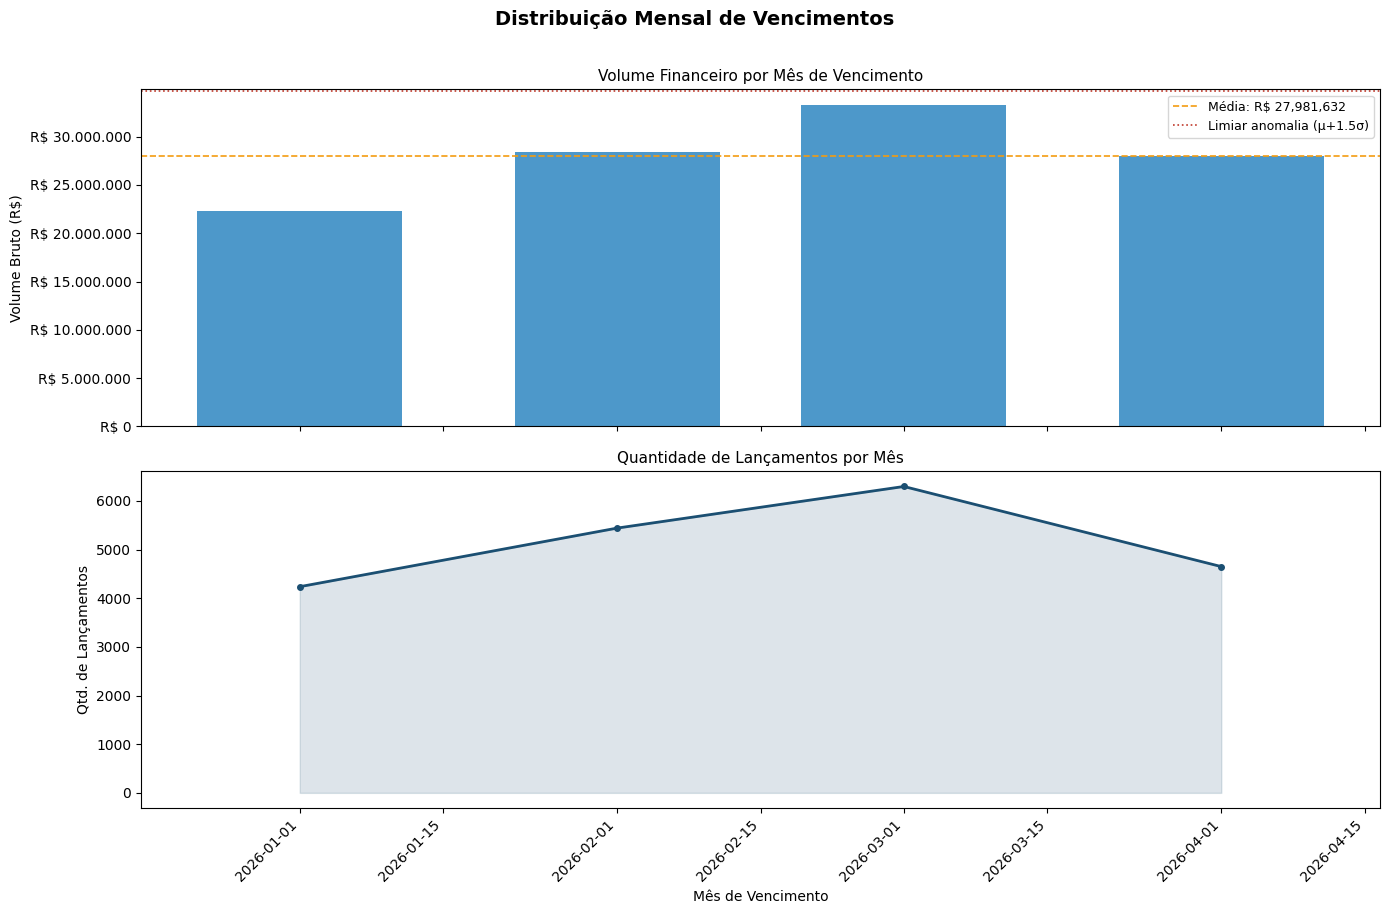


Meses com volume acima do limiar (R$ 34,729,701): 0


In [9]:
PERIODO_INICIO = pd.Timestamp('2025-01-01')
PERIODO_FIM    = pd.Timestamp.today().normalize()

df_valid = df[
    df['data_valida'] &
    df['vencimento'].between(PERIODO_INICIO, PERIODO_FIM)
].copy()
df_valid['mes_ano'] = df_valid['vencimento'].dt.to_period('M')

# Agrega por mês: volume bruto e contagem de lançamentos
temporal = (
    df_valid
    .groupby('mes_ano')
    .agg(volume=('valor_bruto', 'sum'), lancamentos=('lancamento', 'count'))
    .reset_index()
)
temporal['mes_ano_dt'] = temporal['mes_ano'].dt.to_timestamp()

# Destaca meses com volume acima de 1.5x o desvio padrão (anomalias)
media_vol  = temporal['volume'].mean()
std_vol    = temporal['volume'].std()
threshold  = media_vol + 1.5 * std_vol
temporal['anomalia'] = temporal['volume'] > threshold

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Distribuição Mensal de Vencimentos', fontsize=14, fontweight='bold', y=1.01)

# — Gráfico de volume financeiro —
cores_barras = [CORES['perigo'] if a else CORES['secundario'] for a in temporal['anomalia']]
ax1.bar(temporal['mes_ano_dt'], temporal['volume'], color=cores_barras, width=20, alpha=0.85)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax1.set_ylabel('Volume Bruto (R$)', fontsize=10)
ax1.set_title('Volume Financeiro por Mês de Vencimento', fontsize=11)
ax1.axhline(media_vol, color=CORES['destaque'], linestyle='--', linewidth=1.2, label=f'Média: R$ {media_vol:,.0f}')
ax1.axhline(threshold, color=CORES['perigo'],   linestyle=':', linewidth=1.2, label=f'Limiar anomalia (μ+1.5σ)')
ax1.legend(fontsize=9)

# — Gráfico de contagem de lançamentos —
ax2.plot(temporal['mes_ano_dt'], temporal['lancamentos'],
         color=CORES['primario'], linewidth=2, marker='o', markersize=4)
ax2.fill_between(temporal['mes_ano_dt'], temporal['lancamentos'],
                 alpha=0.15, color=CORES['primario'])
ax2.set_ylabel('Qtd. de Lançamentos', fontsize=10)
ax2.set_xlabel('Mês de Vencimento', fontsize=10)
ax2.set_title('Quantidade de Lançamentos por Mês', fontsize=11)

fig.autofmt_xdate(rotation=45)
fig.tight_layout()
plt.show()
plt.close(fig)

n_anomalias = temporal['anomalia'].sum()
print(f"\nMeses com volume acima do limiar (R$ {threshold:,.0f}): {n_anomalias}")
if n_anomalias:
    print(temporal[temporal['anomalia']][['mes_ano','volume','lancamentos']].to_string(index=False))

### Análise por Filial

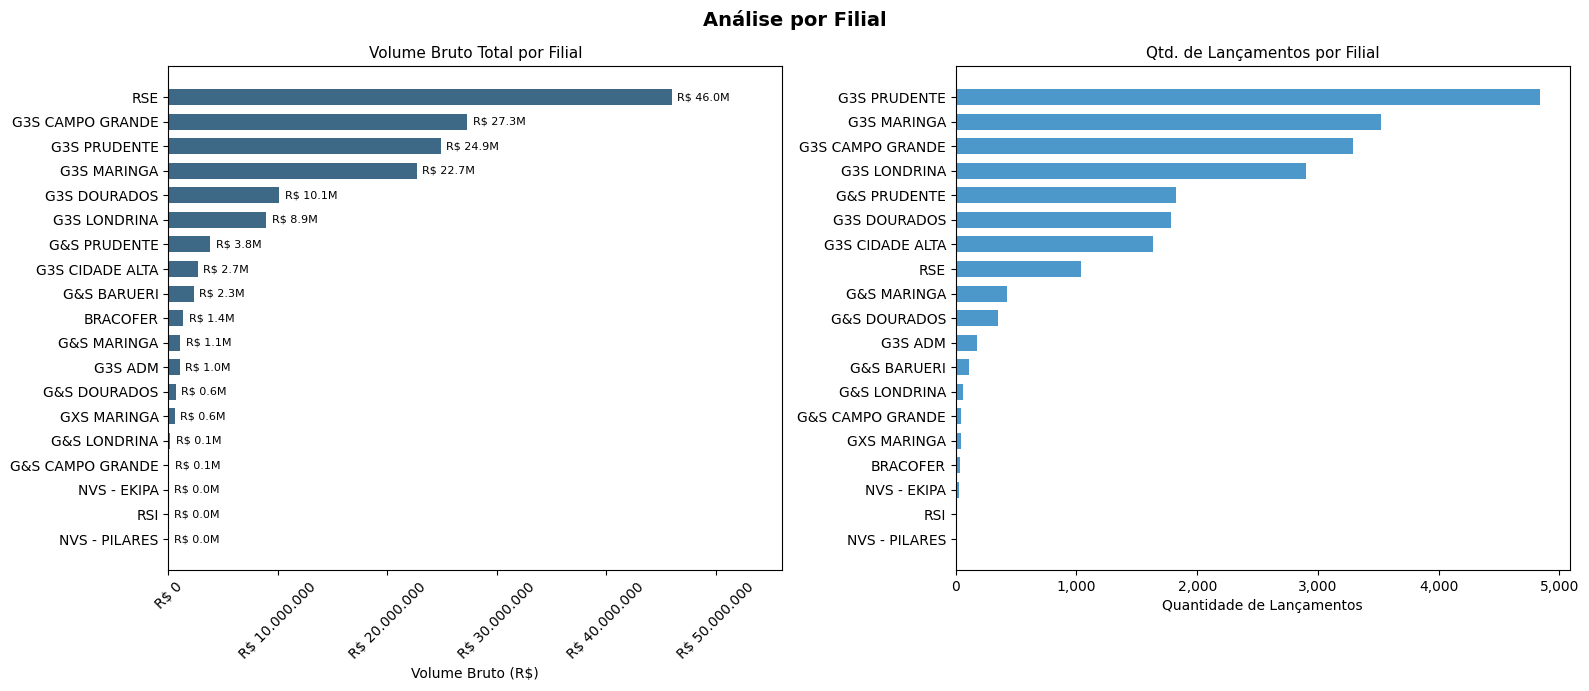


Tabela resumo por filial (ordenada por volume):


,volume_bruto,lancamentos,em_aberto,ticket_medio
filial,,,,
RSE,"R$ 45,977,033.19",1036,"R$ 31,637,467.92","R$ 44,379.38"
G3S CAMPO GRANDE,"R$ 27,323,276.13",3287,"R$ 2,158,998.87","R$ 8,312.53"
G3S PRUDENTE,"R$ 24,871,775.14",4841,"R$ 4,139,431.27","R$ 5,137.74"
G3S MARINGA,"R$ 22,698,885.29",3522,"R$ 5,791,372.85","R$ 6,444.89"
G3S DOURADOS,"R$ 10,140,939.50",1783,"R$ 3,997,547.59","R$ 5,687.57"
G3S LONDRINA,"R$ 8,914,496.21",2901,"R$ 1,688,226.20","R$ 3,072.90"
G&S PRUDENTE,"R$ 3,812,352.71",1823,"R$ 847,498.26","R$ 2,091.25"
G3S CIDADE ALTA,"R$ 2,673,393.78",1636,"R$ 760,454.24","R$ 1,634.10"
G&S BARUERI,"R$ 2,318,083.66",109,"R$ 634,743.28","R$ 21,266.82"


In [10]:
from matplotlib.pyplot import xticks


filial_agg = (
    df.groupby('filial')
    .agg(
        volume_bruto=('valor_bruto', 'sum'),
        lancamentos=('lancamento', 'count'),
        em_aberto=('valor_bruto', lambda x: x[~df.loc[x.index, 'pago']].sum()),
        ticket_medio=('valor_bruto', 'mean'),
    )
    .sort_values('volume_bruto', ascending=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Análise por Filial', fontsize=14, fontweight='bold')

# — Bar chart horizontal: volume bruto —
bars = ax1.barh(filial_agg.index, filial_agg['volume_bruto'],
                color=CORES['primario'], alpha=0.85, height=0.65)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax1.set_xlabel('Volume Bruto (R$)', fontsize=10)
ax1.set_title('Volume Bruto Total por Filial', fontsize=11)
ax1.bar_label(bars,
              labels=[f"R$ {v/1e6:.1f}M" for v in filial_agg['volume_bruto']],
              padding=4, fontsize=8)
ax1.set_xlim(0, filial_agg['volume_bruto'].max() * 1.22)
# Rotaciona os valores do eixo x em 45 graus
for label in ax1.get_xticklabels():
    label.set_rotation(45)

# — Bar chart: quantidade de lançamentos (ordenado do mesmo jeito) —
filial_agg2 = filial_agg.sort_values('lancamentos', ascending=True)
ax2.barh(filial_agg2.index, filial_agg2['lancamentos'],
         color=CORES['secundario'], alpha=0.85, height=0.65)
ax2.set_xlabel('Quantidade de Lançamentos', fontsize=10)
ax2.set_title('Qtd. de Lançamentos por Filial', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
plt.show()
plt.close(fig)

print("\nTabela resumo por filial (ordenada por volume):")
filial_display = filial_agg.sort_values('volume_bruto', ascending=False).copy()
filial_display['volume_bruto'] = filial_display['volume_bruto'].map('R$ {:,.2f}'.format)
filial_display['em_aberto']    = filial_display['em_aberto'].map('R$ {:,.2f}'.format)
filial_display['ticket_medio'] = filial_display['ticket_medio'].map('R$ {:,.2f}'.format)
filial_display

### Análise por Categoria de Lançamento (Top 15)

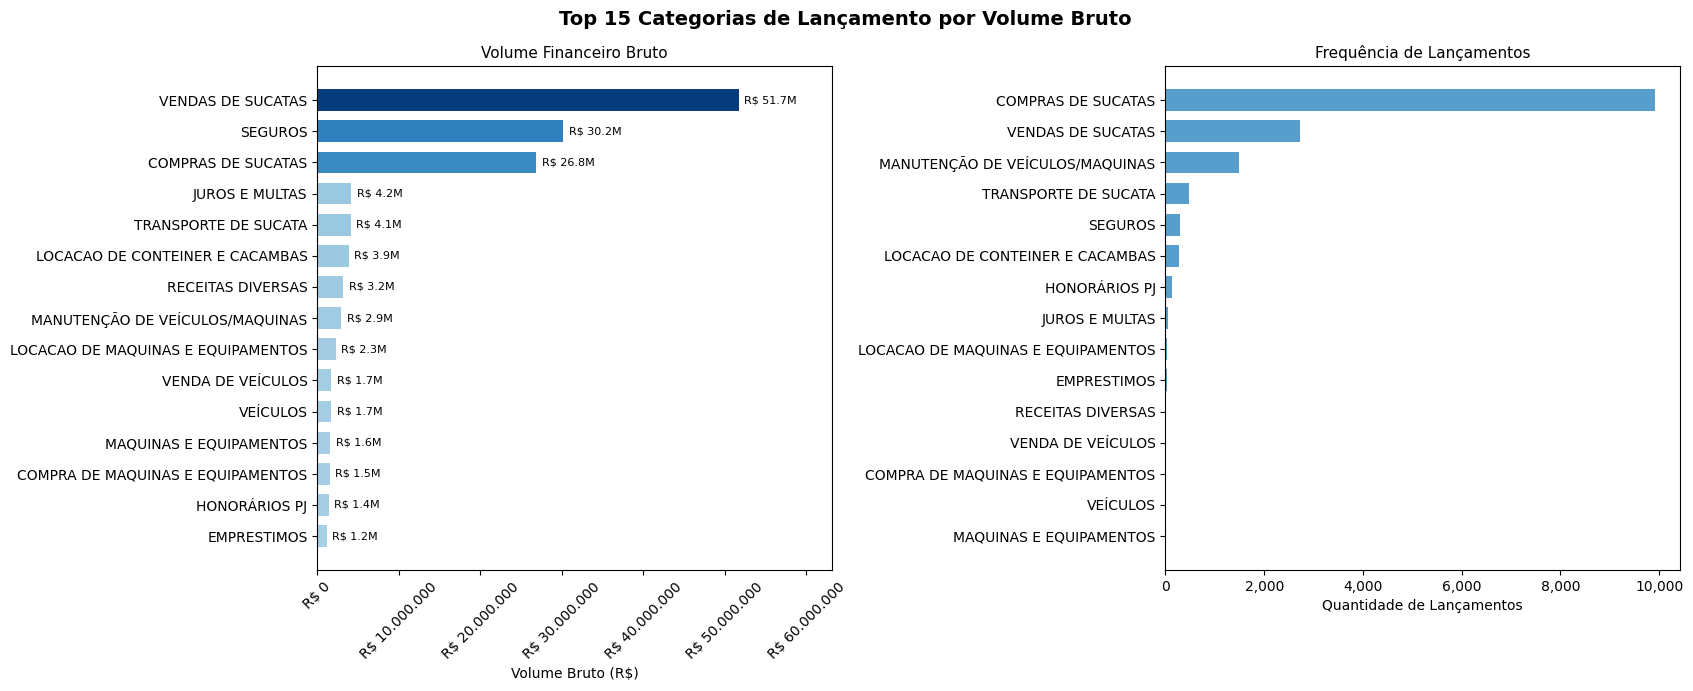


Categorias necessárias para 80% do volume: 7

Top 15 por volume:


,Volume Bruto,Lançamentos,% Volume,% Acumulado
descdc,,,,
VENDAS DE SUCATAS,"R$ 51,725,475.35",2733,33.670726,33.670726
SEGUROS,"R$ 30,180,851.07",293,19.646241,53.316967
COMPRAS DE SUCATAS,"R$ 26,845,108.89",9920,17.474838,70.791806
JUROS E MULTAS,"R$ 4,176,844.74",56,2.718919,73.510725
TRANSPORTE DE SUCATA,"R$ 4,068,251.23",477,2.648230,76.158955
LOCACAO DE CONTEINER E CACAMBAS,"R$ 3,857,020.22",267,2.510729,78.669685
RECEITAS DIVERSAS,"R$ 3,150,911.34",12,2.051087,80.720772
MANUTENÇÃO DE VEÍCULOS/MAQUINAS,"R$ 2,925,641.99",1487,1.904448,82.625220
LOCACAO DE MAQUINAS E EQUIPAMENTOS,"R$ 2,253,187.51",34,1.466714,84.091934


In [11]:
cat_agg = (
    df.groupby('descdc')
    .agg(volume=('valor_bruto', 'sum'), lancamentos=('lancamento', 'count'))
    .sort_values('volume', ascending=False)
)

top15_vol = cat_agg.head(15).sort_values('volume', ascending=True)

# Gradiente de cor proporcional ao volume
norm = plt.Normalize(top15_vol['volume'].min(), top15_vol['volume'].max())
cmap = plt.cm.Blues
cores_cat = [cmap(0.35 + 0.6 * norm(v)) for v in top15_vol['volume']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Top 15 Categorias de Lançamento por Volume Bruto', fontsize=14, fontweight='bold')

# — Gráfico de volume —
bars = ax1.barh(top15_vol.index, top15_vol['volume'], color=cores_cat, height=0.7)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax1.set_xlabel('Volume Bruto (R$)', fontsize=10)
ax1.set_title('Volume Financeiro Bruto', fontsize=11)
ax1.bar_label(bars,
              labels=[f"R$ {v/1e6:.1f}M" for v in top15_vol['volume']],
              padding=4, fontsize=8)
ax1.set_xlim(0, top15_vol['volume'].max() * 1.22)
for label in ax1.get_xticklabels():
    label.set_rotation(45)

# — Gráfico de frequência —
top15_freq = cat_agg.head(15).sort_values('lancamentos', ascending=True)
ax2.barh(top15_freq.index, top15_freq['lancamentos'],
         color=CORES['secundario'], alpha=0.8, height=0.7)
ax2.set_xlabel('Quantidade de Lançamentos', fontsize=10)
ax2.set_title('Frequência de Lançamentos', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.tight_layout()
plt.show()
plt.close(fig)

# Participação acumulada
cat_agg['pct']      = cat_agg['volume'] / cat_agg['volume'].sum() * 100
cat_agg['pct_acum'] = cat_agg['pct'].cumsum()
print(f"\nCategorias necessárias para 80% do volume: {(cat_agg['pct_acum'] <= 80).sum() + 1}")
print("\nTop 15 por volume:")
display(
    cat_agg.head(15)
    .assign(volume=lambda d: d['volume'].map('R$ {:,.2f}'.format))
    .rename(columns={'volume': 'Volume Bruto', 'lancamentos': 'Lançamentos',
                     'pct': '% Volume', 'pct_acum': '% Acumulado'})
)

### Status de Pagamento — Pago vs. Não Pago

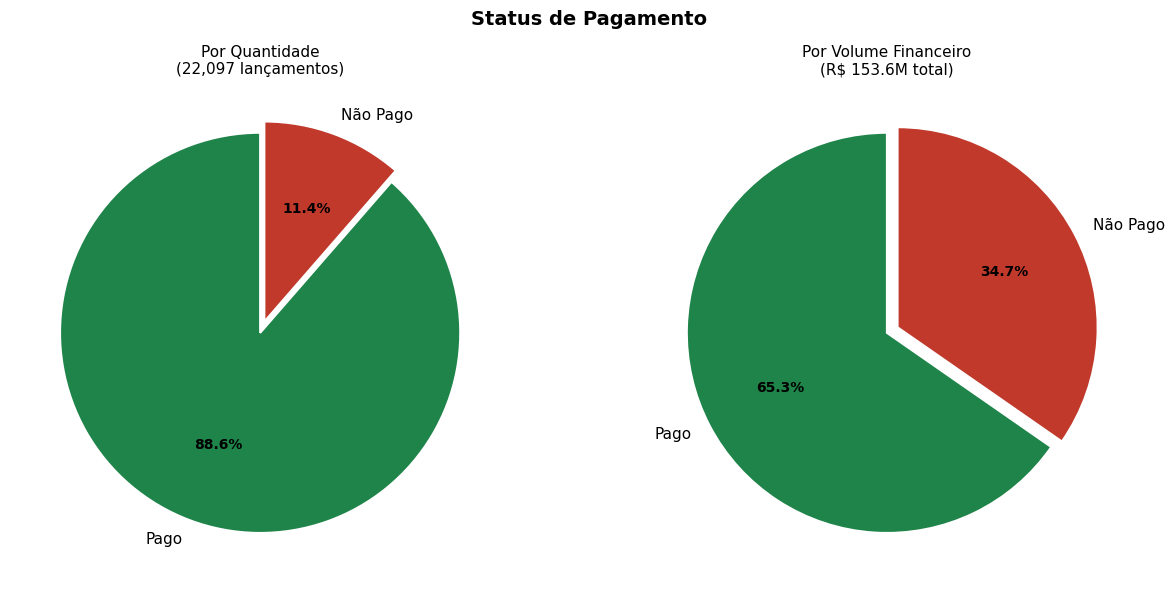

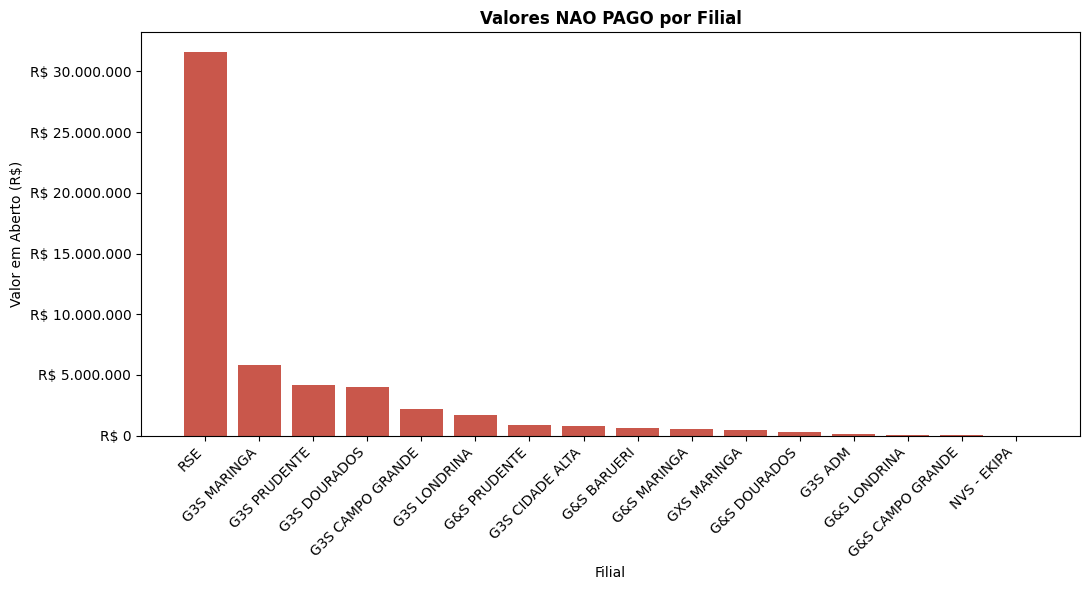


Contas a pagar em aberto por filial:


,Valor em Aberto,Qtd. Pendências
filial,,
RSE,"R$ 31,637,467.92",383
G3S MARINGA,"R$ 5,791,372.85",331
G3S PRUDENTE,"R$ 4,139,431.27",587
G3S DOURADOS,"R$ 3,997,547.59",204
G3S CAMPO GRANDE,"R$ 2,158,998.87",162
G3S LONDRINA,"R$ 1,688,226.20",122
G&S PRUDENTE,"R$ 847,498.26",320
G3S CIDADE ALTA,"R$ 760,454.24",63
G&S BARUERI,"R$ 634,743.28",11


In [12]:
status_counts = df['pago'].value_counts()
status_vol    = df.groupby('pago')['valor_bruto'].sum()

labels   = ['Pago', 'Não Pago']
counts   = [status_counts.get(True, 0), status_counts.get(False, 0)]
volumes  = [status_vol.get(True, 0),    status_vol.get(False, 0)]
explode  = (0, 0.06)
pie_cols = [CORES['sucesso'], CORES['perigo']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Status de Pagamento', fontsize=14, fontweight='bold')

# — Pie: por quantidade —
wedges1, texts1, autotexts1 = ax1.pie(
    counts, labels=labels, autopct='%1.1f%%', explode=explode,
    colors=pie_cols, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)
for at in autotexts1:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax1.set_title(f'Por Quantidade\n({sum(counts):,} lançamentos)', fontsize=11)

# — Pie: por volume financeiro —
wedges2, texts2, autotexts2 = ax2.pie(
    volumes, labels=labels, autopct='%1.1f%%', explode=explode,
    colors=pie_cols, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)
for at in autotexts2:
    at.set_fontsize(10)
    at.set_fontweight('bold')
vol_total = sum(volumes)
ax2.set_title(f'Por Volume Financeiro\n(R$ {vol_total/1e6:.1f}M total)', fontsize=11)

fig.tight_layout()
plt.show()
plt.close(fig)

# — Valores em aberto por filial —
aberto_filial = (
    df[~df['pago']]
    .groupby('filial')
    .agg(valor_em_aberto=('valor_bruto', 'sum'), qtd_pendencias=('lancamento', 'count'))
    .sort_values('valor_em_aberto', ascending=False)
)

fig2, ax3 = plt.subplots(figsize=(11, 6))
ax3.bar(aberto_filial.index, aberto_filial['valor_em_aberto'],
        color=CORES['perigo'], alpha=0.85)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax3.set_xlabel('Filial', fontsize=10)
ax3.set_ylabel('Valor em Aberto (R$)', fontsize=10)
ax3.set_title('Valores NAO PAGO por Filial', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
fig2.tight_layout()
plt.show()
plt.close(fig2)

print("\nContas a pagar em aberto por filial:")
aberto_filial['valor_em_aberto'] = aberto_filial['valor_em_aberto'].map('R$ {:,.2f}'.format)
display(aberto_filial.rename(columns={'valor_em_aberto': 'Valor em Aberto', 'qtd_pendencias': 'Qtd. Pendências'}))

### Análise por Centro de Custo — RECEITA vs DESPESA vs GERAL

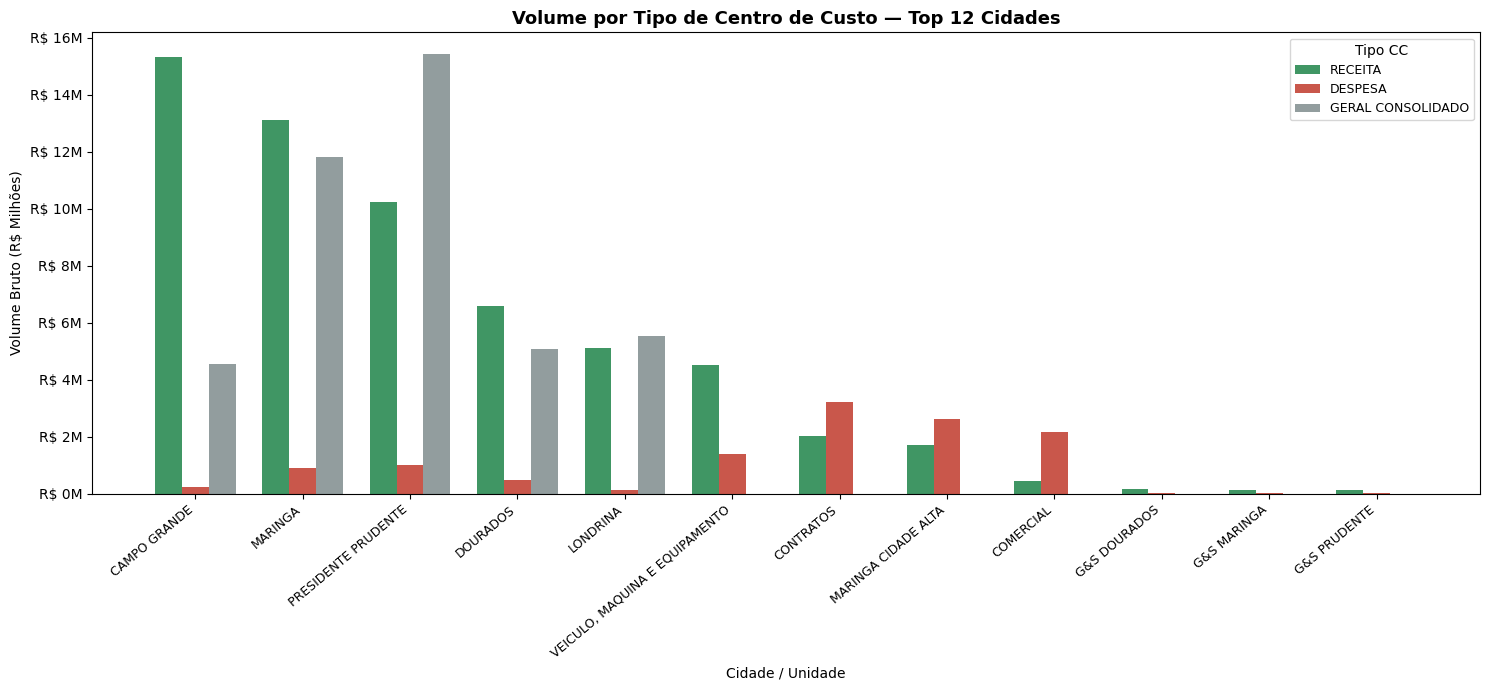


Resumo consolidado por Tipo de Centro de Custo:


,volume,lancamentos,% volume
tipo_cc,,,
RECEITA,"R$ 59,460,380.45",4411,38.7
GERAL CONSOLIDADO,"R$ 46,267,961.89",12436,30.1
DESPESA,"R$ 45,549,840.03",4757,29.7
CONSOLIDADO,"R$ 2,343,319.95",493,1.5


In [20]:
tipos_relevantes = ['RECEITA', 'DESPESA', 'GERAL CONSOLIDADO']
df_cc = df[df['tipo_cc'].isin(tipos_relevantes)].copy()

# Agrega por cidade e tipo (pivot)
cc_pivot = (
    df_cc
    .groupby(['cidade_cc', 'tipo_cc'])['valor_bruto']
    .sum()
    .unstack(fill_value=0)
    .sort_values('RECEITA' if 'RECEITA' in df_cc['tipo_cc'].unique() else df_cc['tipo_cc'].iloc[0], ascending=False)
    .head(12)
)

# Garante que as colunas existam
for col in tipos_relevantes:
    if col not in cc_pivot.columns:
        cc_pivot[col] = 0

x    = np.arange(len(cc_pivot.index))
w    = 0.25
mapa_cores = {
    'RECEITA':          CORES['sucesso'],
    'DESPESA':          CORES['perigo'],
    'GERAL CONSOLIDADO': CORES['neutro'],
}

fig, ax = plt.subplots(figsize=(15, 7))

for i, tipo in enumerate(tipos_relevantes):
    offset = (i - 1) * w
    bars = ax.bar(x + offset, cc_pivot[tipo] / 1e6, width=w,
                  label=tipo, color=mapa_cores[tipo], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cc_pivot.index, rotation=40, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:.0f}M'))
ax.set_ylabel('Volume Bruto (R$ Milhões)', fontsize=10)
ax.set_xlabel('Cidade / Unidade', fontsize=10)
ax.set_title('Volume por Tipo de Centro de Custo — Top 12 Cidades', fontsize=13, fontweight='bold')
ax.legend(title='Tipo CC', fontsize=9)

fig.tight_layout()
plt.show()
plt.close(fig)

# Resumo geral por tipo_cc
print("\nResumo consolidado por Tipo de Centro de Custo:")
resumo_tipo = (
    df.groupby('tipo_cc')
    .agg(volume=('valor_bruto', 'sum'), lancamentos=('lancamento', 'count'))
    .sort_values('volume', ascending=False)
)
resumo_tipo['% volume'] = (resumo_tipo['volume'] / resumo_tipo['volume'].sum() * 100).round(1)
resumo_tipo['volume']   = resumo_tipo['volume'].map('R$ {:,.2f}'.format)
display(resumo_tipo)

### Detecção de Outliers — valor_bruto

Q1: R$ 183.00  |  Q3: R$ 2,731.66  |  IQR: R$ 2,548.66
Limite superior (Q3 + 1.5×IQR): R$ 6,554.65
Registros identificados como outliers: 3836 (17.4%)


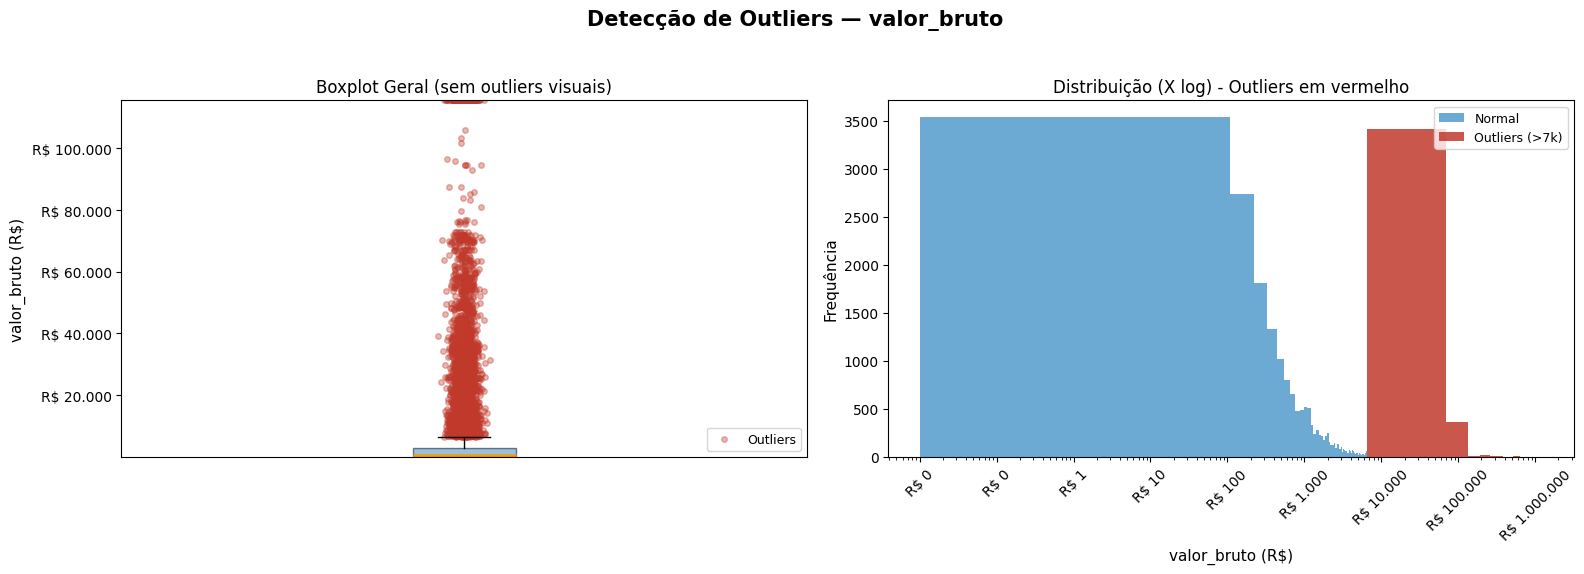


Outliers acima de R$ 100.000 (332 registros):


,documento,nome,descdc,filial,valor_bruto,iterea_pagamento,vencimento
58117,00007955,HIDROEUROPA S.L. 0232,MAQUINAS E EQUIPAMENTOS,G3S CAMPO GRANDE,"R$ 1,258,158.92",2026-01-27,2026-01-27
65250,DEV. GLE 450 - NFE 9.354,ITATIAIA DISTRIBUIDORA DE VEICULOS LTDA,VENDA DE VEÍCULOS,RSE,"R$ 760,000.00",2026-02-25,2026-02-13
48487,NFE-108115,ITATIAIA DISTRIBUIDORA DE VEICULOS LTDA,VEÍCULOS,RSE,"R$ 760,000.00",2026-01-26,2026-01-26
6450,ADT-23032026-2,ZHEJIANG MINXIN MATERIALES DE CONSTRUCCION S.R...,VENDAS DE SUCATAS,G3S CAMPO GRANDE,"R$ 629,463.56",2026-03-23,2026-03-23
11777,ADT-20032026-1,ZHEJIANG MINXIN MATERIALES DE CONSTRUCCION S.R...,VENDAS DE SUCATAS,G3S CAMPO GRANDE,"R$ 629,463.55",2026-03-23,2026-03-23
...,...,...,...,...,...,...,...
28603,SEGURO-FROTA2026,BRADESCO AUTO / SEGURO,SEGUROS,RSE,"R$ 115,543.10",2026-04-20,2026-04-20
29195,SEGURO-FROTA2026,BRADESCO AUTO / SEGURO,SEGUROS,RSE,"R$ 115,543.10",NAO PAGO,2026-11-18
31191,FAT2022026,ARCELORMITTAL BRASIL,LOCACAO DE MAQUINAS E EQUIPAMENTOS,G&S BARUERI,"R$ 106,029.00",2026-03-05,2026-03-05
11737,FAT2052026,ARCELORMITTAL BRASIL,LOCACAO DE MAQUINAS E EQUIPAMENTOS,G&S BARUERI,"R$ 103,361.19",2026-03-23,2026-03-23


In [21]:
vb = df['valor_bruto'].dropna()

Q1  = vb.quantile(0.25)
Q3  = vb.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df[df['valor_bruto'] > limite_sup].copy()
n_out    = len(outliers)

print(f"Q1: R$ {Q1:,.2f}  |  Q3: R$ {Q3:,.2f}  |  IQR: R$ {IQR:,.2f}")
print(f"Limite superior (Q3 + 1.5×IQR): R$ {limite_sup:,.2f}")
print(f"Registros identificados como outliers: {n_out} ({n_out/len(df)*100:.1f}%)")

# — Visualização aprimorada dos outliers —

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Detecção de Outliers — valor_bruto', fontsize=15, fontweight='bold')

# Boxplot melhorado: Sem outliers no eixo (“showfliers=False”) para escala legível
boxprops = dict(facecolor=CORES['secundario'], alpha=0.5)
medianprops = dict(color=CORES['destaque'], linewidth=2)

# Limita o eixo y para esconder valores extremos e realçar a caixinha
ax1.boxplot(
    vb, vert=True, patch_artist=True, showfliers=False, 
    boxprops=boxprops, medianprops=medianprops
)
ax1.set_ylim([vb.min(), np.percentile(vb, 99.5)])  # Mostra 99,5% dos dados para escala realista
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax1.set_ylabel('valor_bruto (R$)', fontsize=11)
ax1.set_title('Boxplot Geral (sem outliers visuais)', fontsize=12)
ax1.set_xticks([])

# Extra: Adiciona um swarmplot/strip dos outliers acima do limite (visivelmente destacados)
outlier_points = vb[vb > limite_sup]
if not outlier_points.empty:
    jitter = np.random.normal(1.0, 0.01, size=len(outlier_points))  # Para espalhar visualmente
    ax1.scatter(
        jitter, outlier_points, 
        color=CORES['perigo'], alpha=0.36, marker='o', s=16, label='Outliers' if len(outlier_points) > 0 else None
    )
    ax1.legend(fontsize=9, loc='lower right')

# Histograma (com escala log para eixo x): Permite ver melhor a cauda longa
counts, bins, patches = ax2.hist(
    vb[vb <= limite_sup], bins=60,
    color=CORES['secundario'], alpha=0.7, label='Normal'
)
# Sobrepõe histogram dos outliers
ax2.hist(
    vb[vb > limite_sup], bins=20,
    color=CORES['perigo'], alpha=0.85,
    label=f'Outliers (>{limite_sup/1e3:.0f}k)'
)
ax2.set_xlabel('valor_bruto (R$)', fontsize=11)
ax2.set_ylabel('Frequência', fontsize=11)
ax2.set_title('Distribuição (X log) - Outliers em vermelho', fontsize=12)
ax2.set_xscale('log')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_brl))
ax2.legend(fontsize=9)
for label in ax2.get_xticklabels(): 
    label.set_rotation(45)

fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Deixa espaço pro título
plt.show()
plt.close(fig)

# — Tabela de outliers relevantes (acima de R$ 100k) —
outliers_relevantes = (
    outliers[outliers['valor_bruto'] > 100_000]
    [['documento', 'nome', 'descdc', 'filial', 'valor_bruto',
      'iterea_pagamento', 'vencimento']]
    .sort_values('valor_bruto', ascending=False)
)

print(f"\nOutliers acima de R$ 100.000 ({len(outliers_relevantes)} registros):")
outliers_relevantes_display = outliers_relevantes.copy()
outliers_relevantes_display['valor_bruto'] = outliers_relevantes_display['valor_bruto'].map('R$ {:,.2f}'.format)
display(outliers_relevantes_display)

### Consulta de Lançamentos por Centro de Custo

Como muitos lançamentos passam por **rateio** entre centros de custo, a análise por filial pode distorcer o real peso de cada área. A estrutura correta de análise é a **hierarquia do campo `descen`**, que classifica cada lançamento em 4 níveis:

| Nível | Coluna | Exemplo de Valores |
|---|---|---|
| 1 — Tipo | `tipo_cc` | RECEITA · DESPESA · GERAL CONSOLIDADO |
| 2 — Divisão | `divisao_cc` | SELETIVA · PILARES · EKIPA |
| 3 — Unidade | `cidade_cc` | PRESIDENTE PRUDENTE · MARINGÁ · LONDRINA |
| 4 — Setor | `dept_cc` | COMERCIAL · ADMINISTRATIVO · VEÍCULOS |

O widget abaixo permite navegar essa hierarquia de forma **cascata e interativa**:

- Selecione um **Tipo CC** → os filtros de Divisão são atualizados automaticamente  
- Selecione uma **Divisão** → as Unidades disponíveis são filtradas  
- Selecione uma **Unidade** → apenas os Setores dessa unidade aparecem  
- O gráfico e a tabela sempre mostram o **próximo nível** da hierarquia, com drill-down automático  
- O filtro de **Status** cruza o resultado com o status de pagamento

> 💡 Para análises com rateio mais preciso, o campo `valor_centro` (em vez de `valor_bruto`) reflete o valor efetivamente alocado a cada centro de custo.

In [15]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Widgets ───────────────────────────────────────────────────────────────────
_dd_layout  = widgets.Layout(width='220px')
_txt_layout = widgets.Layout(width='460px')

ANO_MIN = 2026

w_busca = widgets.Text(
    description='Busca:',
    placeholder='descdc, codcdc, nome, codcen, descen — qualquer trecho...',
    layout=_txt_layout,
)
w_status = widgets.RadioButtons(
    options=['Todos', 'Pagos', 'Em aberto'],
    description='Status:',
    layout=widgets.Layout(width='220px'),
)

_anos_base = df.loc[df['data_valida'], 'vencimento'].dt.year.dropna().astype(int)
_anos_validos = sorted(_anos_base[_anos_base >= ANO_MIN].unique().tolist())

if not _anos_validos:
    _anos_validos = [ANO_MIN]

w_ano_ini = widgets.Dropdown(
    description='De (ano):', options=_anos_validos, value=ANO_MIN, layout=_dd_layout
)
w_ano_fim = widgets.Dropdown(
    description='Até (ano):', options=_anos_validos, value=_anos_validos[-1], layout=_dd_layout
)
out_area = widgets.Output()

# ── Colunas exibidas na tabela ────────────────────────────────────────────────
_COLS = {
    'lancamento':   'ID Lançamento',
    'codcen':       'Cód. CC',
    'descen':       'Centro de Custo',
    'codcdc':       'Cód. Categ.',
    'descdc':       'Categoria',
    'nome':         'Fornecedor / Cliente',
    'vencimento':   'Vencimento',
    'valor_bruto':  'Valor Bruto',
    'valor_plano':  'Valor Plano',
    'valor_centro': 'Valor Centro',
    'pago':         'Pago',
    'filial':       'Filial',
}
_CAMPOS_BUSCA = ['descdc', 'codcdc', 'nome', 'codcen', 'descen']

# ── Atualização da tabela ─────────────────────────────────────────────────────
def _refresh(*_):
    with out_area:
        clear_output(wait=True)

        mask = pd.Series([True] * len(df), index=df.index)

        # status de pagamento
        if w_status.value == 'Pagos':
            mask &= df['pago']
        elif w_status.value == 'Em aberto':
            mask &= ~df['pago']

        # intervalo de datas (sempre de 2025 em diante)
        ano_ini = max(w_ano_ini.value, ANO_MIN)
        ano_fim = w_ano_fim.value
        if ano_ini > ano_fim:
            ano_ini, ano_fim = ano_fim, ano_ini

        mask &= (
            df['data_valida'] &
            (df['vencimento'].dt.year >= ANO_MIN) &
            df['vencimento'].dt.year.between(ano_ini, ano_fim)
        )

        # busca textual (OR entre os campos)
        termo = w_busca.value.strip()
        if termo:
            texto_mask = pd.Series([False] * len(df), index=df.index)
            for col in _CAMPOS_BUSCA:
                texto_mask |= df[col].astype(str).str.contains(termo, case=False, na=False)
            mask &= texto_mask

        df_sel = df.loc[mask, list(_COLS.keys())].copy()
        n = len(df_sel)
        print(f"Registros encontrados: {n:,}")

        if n == 0:
            print("Nenhum registro encontrado para os filtros selecionados.")
            return

        aviso = ''
        if n > 500:
            aviso = f'  ⚠️ Exibindo 500 de {n:,} — refine a busca para ver todos.'
            df_sel = df_sel.head(500)

        df_disp = df_sel.rename(columns=_COLS).copy()
        df_disp['Vencimento']    = df_disp['Vencimento'].dt.strftime('%d/%m/%Y')
        df_disp['Valor Bruto']   = df_disp['Valor Bruto'].map('R$ {:,.2f}'.format)
        df_disp['Valor Plano']   = df_disp['Valor Plano'].map('R$ {:,.2f}'.format)
        df_disp['Valor Centro']  = df_disp['Valor Centro'].map('R$ {:,.2f}'.format)
        df_disp['Pago']          = df_disp['Pago'].map({True: 'Sim', False: 'Não'})

        if aviso:
            print(aviso)
        with pd.option_context('display.max_rows', None, 'display.max_colwidth', 60):
            display(df_disp.reset_index(drop=True))

# ── Observers ────────────────────────────────────────────────────────────────
w_busca.observe(_refresh, names='value')
w_status.observe(_refresh, names='value')
w_ano_ini.observe(_refresh, names='value')
w_ano_fim.observe(_refresh, names='value')

# ── Layout ────────────────────────────────────────────────────────────────────
ui = widgets.VBox([
    widgets.HTML('<b style="font-size:14px">🔎 Consulta de Lançamentos</b>'),
    w_busca,
    widgets.HBox([w_ano_ini, w_ano_fim], layout=widgets.Layout(gap='16px')),
    w_status,
    out_area,
])
_refresh()
display(ui)

---

### QA — Flags de Atenção

Verificação automática de registros que exigem atenção antes de análises de rentabilidade.

| Flag | O que detecta |
|---|---|
| **Contas Genéricas** | `codcdc` em `5.4.6`, `5.4.11`, `7.11.4`, `7.11.6`, `7.1.16` — escondem natureza real do lançamento |
| **CC Familiar** | `codcen` começa com `1.9` / `2.9` — gastos pessoais dos sócios |
| **Intercompany** | `codcen` em `1.10.1` / `2.10.1` — operações entre empresas do grupo |
| **Saldo Legado** | `data_valida == False` — datas `1800-01-01`, saldos migrados do sistema antigo |
| **Devolução Cruzada** | Devoluções (`6.4.1`, `4.3.1`) lançadas em CC de receita (`codcen` começa com `2`) — risco de DRE inflado |

In [16]:
CONTAS_GENERICAS = ['5.4.6', '5.4.11', '7.11.4', '7.11.6', '7.1.16']

flags = {
    'Contas Genéricas': df['codcdc'].isin(CONTAS_GENERICAS),
    'CC Familiar (sócios)': df['codcen'].str.startswith(('1.9', '2.9'), na=False),
    'Intercompany': df['codcen'].isin(['1.10.1', '2.10.1']),
    'Saldo Legado (data inválida)': ~df['data_valida'],
    'Devolução Cruzada': (
        df['codcdc'].isin(['6.4.1', '4.3.1']) &
        df['codcen'].str.startswith('2', na=False)
    ),
}

resumo_qa = pd.DataFrame([
    {
        'Flag': nome,
        'Registros': int(mask.sum()),
        'Valor Bruto (R$)': df.loc[mask, 'valor_bruto'].sum(),
        '% do Total': f"{mask.sum() / len(df) * 100:.2f}%",
    }
    for nome, mask in flags.items()
])

resumo_qa['Valor Bruto (R$)'] = resumo_qa['Valor Bruto (R$)'].map('R$ {:,.2f}'.format)
print("=== QA — FLAGS DE ATENÇÃO ===\n")
display(resumo_qa.style.hide(axis='index'))

=== QA — FLAGS DE ATENÇÃO ===



Flag,Registros,Valor Bruto (R$),% do Total
Contas Genéricas,97,"R$ 3,268,078.30",0.44%
CC Familiar (sócios),68,"R$ 1,276,983.12",0.31%
Intercompany,46,"R$ 611,576.60",0.21%
Saldo Legado (data inválida),0,R$ 0.00,0.00%
Devolução Cruzada,1,"R$ 1,628.00",0.00%


---

### Análise por Divisão do Grupo

Volume bruto por unidade de negócio — mapeado a partir do prefixo de `codcen`.

O grupo G3S opera com múltiplos CNPJs integrados:

| Divisão | Código CC | Atividade |
|---|---|---|
| Seletiva | 1.2 / 2.2 | Core business — compra e venda de sucata |
| G3S Escritório (Pilares) | 1.1 / 2.1 | Holding corporativa |
| Bracofer | 1.3 / 2.3 | Distribuição de ferro novo |
| Transmove GSL | 1.4 / 2.4 | Transportadora do grupo |
| Ekipa Contêiner | 1.5 / 2.5 | Locação de contêineres e caçambas |
| Ekipa RSE | 1.6 / 2.6 | Locação de veículos e máquinas pesadas |
| Ekipa G&S | 1.7 / 2.7 | Serviços em clientes siderúrgicos externos |
| Render / Imobiliária | 1.8 / 2.8 | Portfólio imobiliário |
| Familiar | 1.9 / 2.9 | Gastos pessoais dos sócios |
| Intercompany | 1.10 / 2.10 | Operações entre empresas do grupo |
| NVS Entulho | 1.12 / 2.12 | Coleta de entulho e resíduos |

> Intercompany e Familiar são excluídos do gráfico para não distorcer os volumes operacionais.

Registros: 22,097  |  Divisões mapeadas: 9



Divisão,Lançamentos,Volume Bruto
Seletiva,18466,"R$ 95,126,045"
Ekipa G&S,1553,"R$ 32,865,904"
Ekipa RSE,551,"R$ 10,442,860"
G3S Escritório,557,"R$ 6,091,276"
Ekipa Contêiner,399,"R$ 4,113,026"
Bracofer,310,"R$ 1,255,539"
Transmove GSL,109,"R$ 187,364"
Render/Imobiliária,27,"R$ 41,277"
NVS Entulho,9,"R$ 6,132"


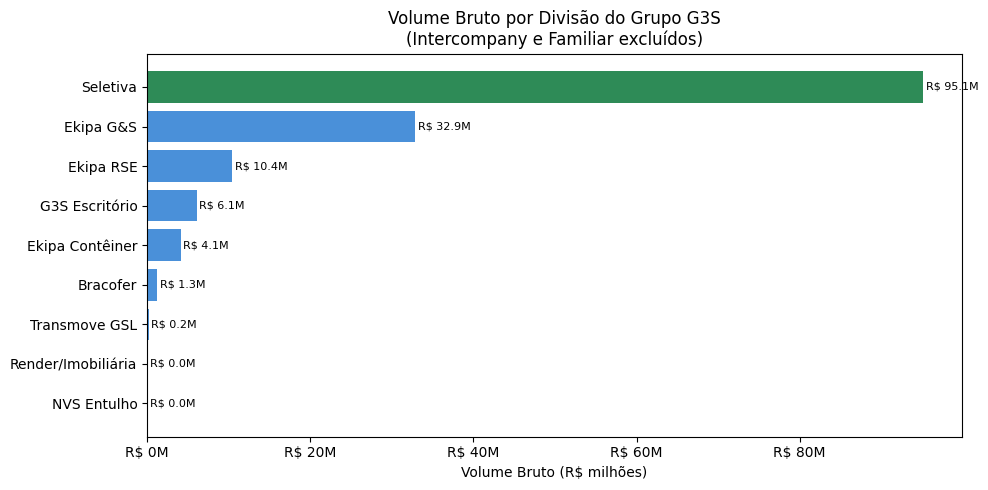

In [17]:
MAPA_DIVISAO = {
    '1.1': 'G3S Escritório', '2.1': 'G3S Escritório',
    '1.2': 'Seletiva',       '2.2': 'Seletiva',
    '1.3': 'Bracofer',       '2.3': 'Bracofer',
    '1.4': 'Transmove GSL',  '2.4': 'Transmove GSL',
    '1.5': 'Ekipa Contêiner','2.5': 'Ekipa Contêiner',
    '1.6': 'Ekipa RSE',      '2.6': 'Ekipa RSE',
    '1.7': 'Ekipa G&S',      '2.7': 'Ekipa G&S',
    '1.8': 'Render/Imobiliária', '2.8': 'Render/Imobiliária',
    '1.9': 'Familiar',       '2.9': 'Familiar',
    '1.10': 'Intercompany',  '2.10': 'Intercompany',
    '1.11': 'Render (Rec.)', '2.11': 'Render (Rec.)',
    '1.12': 'NVS Entulho',   '2.12': 'NVS Entulho',
}

EXCLUIR_DIVISAO = {'Familiar', 'Intercompany'}

prefixo_cc = df['codcen'].str.extract(r'^(\d+\.\d+)')[0]
df['divisao_grupo'] = prefixo_cc.map(MAPA_DIVISAO).fillna('Outros')

resumo_div = (
    df[~df['divisao_grupo'].isin(EXCLUIR_DIVISAO)]
    .groupby('divisao_grupo')
    .agg(
        volume_total=('valor_bruto', 'sum'),
        qtd_lancamentos=('lancamento', 'count'),
    )
    .sort_values('volume_total', ascending=False)
    .reset_index()
)

resumo_div['volume_fmt'] = resumo_div['volume_total'].map('R$ {:,.0f}'.format)
print(f"Registros: {len(df):,}  |  Divisões mapeadas: {resumo_div.shape[0]}\n")
display(resumo_div[['divisao_grupo', 'qtd_lancamentos', 'volume_fmt']]
        .rename(columns={'divisao_grupo': 'Divisão', 'qtd_lancamentos': 'Lançamentos', 'volume_fmt': 'Volume Bruto'})
        .style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(10, 5))
cores_bar = ['#2E8B57' if v == resumo_div['volume_total'].max() else '#4A90D9'
             for v in resumo_div['volume_total']]
bars = ax.barh(resumo_div['divisao_grupo'], resumo_div['volume_total'] / 1e6, color=cores_bar)

ax.set_xlabel('Volume Bruto (R$ milhões)')
ax.set_title('Volume Bruto por Divisão do Grupo G3S\n(Intercompany e Familiar excluídos)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}M'))
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f'R$ {w:.1f}M', va='center', fontsize=8)

fig.tight_layout()
plt.show()
plt.close(fig)

---

### DRE Gerencial Simplificado

Demonstração de resultado estimada a partir dos grupos do Plano de Contas (`grupo_pc`).

| Grupo | Categoria | Papel na DRE |
|---|---|---|
| **4** | Receita Sucata | (+) Receita Bruta |
| **5** | Outras Receitas | (+) Receitas Não-Operacionais |
| **6** | Custos | (–) CPV / Custo das Mercadorias |
| **7** | Despesas Gerais | (–) Despesas Operacionais |
| **8** | Aquisições | Não compõe resultado (imobilizado) |
| **9** | Imobiliária | (–) Despesas Imobiliárias |

> **Premissas:** filtro `data_valida == True`, exclusão de Intercompany (`codcen` iniciando com `1.10` ou `2.10`) e de saldos migrados (`documento` contendo `'SALDO'`).

> **Atenção:** `valor_plano` negativo = despesa, positivo = receita. A DRE aqui usa `valor_plano` para respeitar o sinal contábil.

In [18]:
mask_dre = (
    df['data_valida'] &
    ~df['codcen'].str.startswith(('1.10', '2.10'), na=False) &
    ~df['documento'].str.upper().str.contains('SALDO', na=False)
)
df_dre = df.loc[mask_dre].copy()

MAPA_DRE = {
    '4': ('Receita Sucata',         'receita'),
    '5': ('Outras Receitas',        'receita'),
    '6': ('Custos (CPV)',           'custo'),
    '7': ('Despesas Gerais',        'despesa'),
    '8': ('Aquisições (Imobilizado)', 'aquisicao'),
    '9': ('Despesas Imobiliárias',  'despesa'),
}

linhas_dre = []
for grupo, (descricao, papel) in MAPA_DRE.items():
    sub = df_dre.loc[df_dre['grupo_pc'] == grupo, 'valor_plano']
    soma = sub.sum()
    linhas_dre.append({
        'Grupo': grupo,
        'Categoria': descricao,
        'Soma valor_plano': soma,
        'Papel': papel,
    })

dre = pd.DataFrame(linhas_dre)

receita_sucata   = dre.loc[dre['Grupo'] == '4', 'Soma valor_plano'].values[0]
outras_receitas  = dre.loc[dre['Grupo'] == '5', 'Soma valor_plano'].values[0]
custos           = dre.loc[dre['Grupo'] == '6', 'Soma valor_plano'].values[0]
despesas_gerais  = dre.loc[dre['Grupo'] == '7', 'Soma valor_plano'].values[0]
desp_imob        = dre.loc[dre['Grupo'] == '9', 'Soma valor_plano'].values[0]

margem_bruta     = receita_sucata + custos
resultado_op     = margem_bruta + outras_receitas + despesas_gerais + desp_imob

linhas_resultado = [
    {'Linha DRE': 'Receita Sucata (grupo 4)',      'Valor (R$)': receita_sucata},
    {'Linha DRE': '(–) Custos CPV (grupo 6)',      'Valor (R$)': custos},
    {'Linha DRE': '= Margem Bruta Sucata',         'Valor (R$)': margem_bruta},
    {'Linha DRE': '(+) Outras Receitas (grupo 5)', 'Valor (R$)': outras_receitas},
    {'Linha DRE': '(–) Despesas Gerais (grupo 7)', 'Valor (R$)': despesas_gerais},
    {'Linha DRE': '(–) Desp. Imobiliárias (gr. 9)','Valor (R$)': desp_imob},
    {'Linha DRE': '= Resultado Operacional Est.',  'Valor (R$)': resultado_op},
]

df_resultado = pd.DataFrame(linhas_resultado)
df_resultado['Valor (R$)'] = df_resultado['Valor (R$)'].map('R$ {:,.2f}'.format)

print("=== DRE GERENCIAL SIMPLIFICADO ===")
print(f"Base: {mask_dre.sum():,} registros válidos  |  Período: {df_dre['vencimento'].min().date()} a {df_dre['vencimento'].max().date()}\n")
display(df_resultado.style.hide(axis='index'))

print(f"\n  Margem Bruta Sucata:       R$ {margem_bruta:>15,.2f}")
print(f"  Resultado Operacional Est: R$ {resultado_op:>15,.2f}")

=== DRE GERENCIAL SIMPLIFICADO ===
Base: 22,049 registros válidos  |  Período: 2026-01-01 a 2027-03-15



Linha DRE,Valor (R$)
Receita Sucata (grupo 4),"R$ 49,823,643.34"
(–) Custos CPV (grupo 6),"R$ -25,690,821.46"
= Margem Bruta Sucata,"R$ 24,132,821.88"
(+) Outras Receitas (grupo 5),"R$ 9,205,787.85"
(–) Despesas Gerais (grupo 7),"R$ -14,382,268.55"
(–) Desp. Imobiliárias (gr. 9),"R$ -7,263.00"
= Resultado Operacional Est.,"R$ 18,949,078.18"



  Margem Bruta Sucata:       R$   24,132,821.88
  Resultado Operacional Est: R$   18,949,078.18


---

### Contas a Pagar em Aberto — Aging

Posição atual dos lançamentos **não pagos** com data válida, classificados por faixa de vencimento em relação a hoje.

| Faixa | Critério |
|---|---|
| **A vencer (0–30 dias)** | `vencimento` entre hoje e hoje+30 |
| **A vencer (31–60 dias)** | `vencimento` entre hoje+31 e hoje+60 |
| **A vencer (61–90 dias)** | `vencimento` entre hoje+61 e hoje+90 |
| **A vencer (90+ dias)** | `vencimento` > hoje+90 |
| **Vencidos (0–30 dias)** | `vencimento` entre hoje-30 e hoje-1 |
| **Vencidos (31–60 dias)** | `vencimento` entre hoje-60 e hoje-31 |
| **Vencidos (61–90 dias)** | `vencimento` entre hoje-90 e hoje-61 |
| **Vencidos (90+ dias)** | `vencimento` < hoje-90 |

=== CONTAS A PAGAR EM ABERTO — 2026-04-24 ===

  Total em aberto:     2,518 lançamentos  |  R$ 53,252,280.97
  Destes, VENCIDOS:    1,125 lançamentos  |  R$ 11,614,712.52



Faixa,Registros,Valor Total (R$)
Vencido — 90+ dias,33,"R$ 84,481.51"
Vencido — 61 a 90 dias,69,"R$ 1,098,454.34"
Vencido — 31 a 60 dias,119,"R$ 2,339,475.19"
Vencido — 0 a 30 dias,904,"R$ 8,092,301.48"
A vencer — 0 a 30 dias,956,"R$ 17,338,748.83"
A vencer — 31 a 60 dias,118,"R$ 4,203,591.22"
A vencer — 61 a 90 dias,69,"R$ 3,780,998.22"
A vencer — 90+ dias,250,"R$ 16,314,230.18"



--- TOP 10 CREDORES COM MAIOR SALDO EM ABERTO ---



Credor,Lançamentos,Saldo em Aberto (R$)
BRADESCO AUTO / SEGURO,215,"R$ 24,074,417.96"
GERDAU ACOS LONGOS SA,102,"R$ 4,907,318.93"
ZHEJIANG MINXIN MATERIALES DE CONSTRUCCION S.R.L SUCURSAL B,134,"R$ 4,664,386.73"
G3S COMERCIO E INDUSTRIA DE FERRO E ACO LTDA,268,"R$ 3,879,829.33"
GV DO BRASIL INDUSTRIA E COMERCIO DE ACO LTDA,57,"R$ 3,336,358.12"
GSL LOGISTICA E TRANSPORTE LTDA,162,"R$ 1,484,614.67"
BRUNO INDUSTRIAL LTDA,4,"R$ 1,400,000.00"
MB CRUSHER DO BRASIL COMERCIO DE EQUIPAMENTOS LTDA,5,"R$ 1,270,000.00"
G&S TRANSPORTE LOGISTICA E LOCACAO DE MAQUINAS E EQUIPAMENTO,195,"R$ 731,420.88"
RSE COMERCIO DE FERRO ACO DE EQUIPAMENTOS LTDA,45,"R$ 542,580.87"


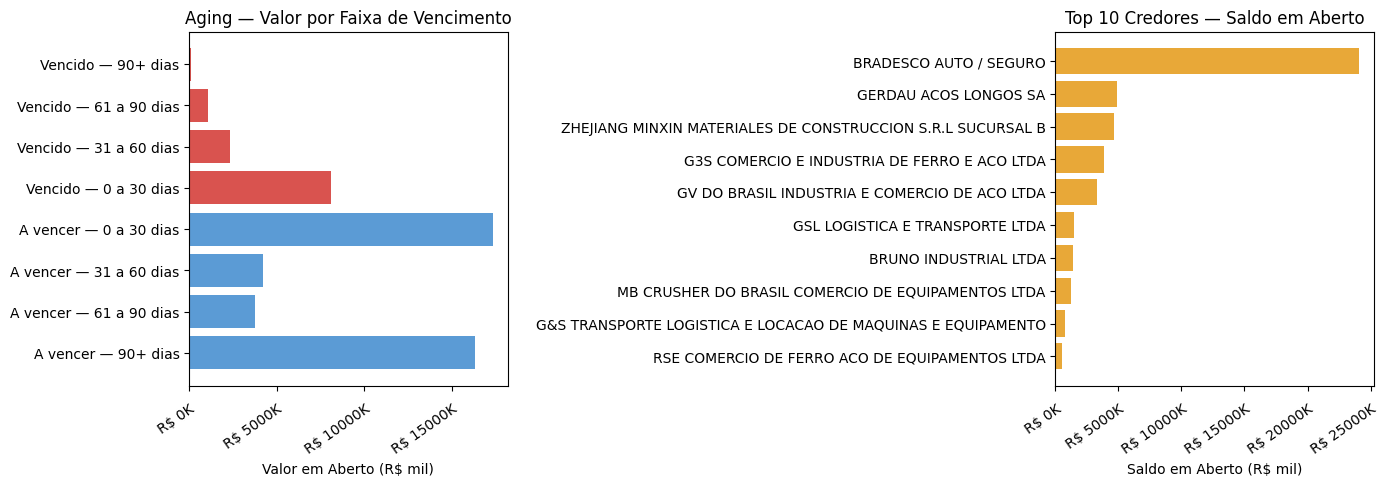

In [19]:
HOJE = pd.Timestamp.today().normalize()

df_aberto = df.loc[
    (~df['pago']) & df['data_valida']
] .copy()

df_aberto['dias_ate_venc'] = (df_aberto['vencimento'] - HOJE).dt.days

def classificar_aging(dias):
    if dias >= 0:
        if dias <= 30:   return 'A vencer — 0 a 30 dias'
        elif dias <= 60: return 'A vencer — 31 a 60 dias'
        elif dias <= 90: return 'A vencer — 61 a 90 dias'
        else:            return 'A vencer — 90+ dias'
    else:
        d = abs(dias)
        if d <= 30:   return 'Vencido — 0 a 30 dias'
        elif d <= 60: return 'Vencido — 31 a 60 dias'
        elif d <= 90: return 'Vencido — 61 a 90 dias'
        else:         return 'Vencido — 90+ dias'

ORDEM_AGING = [
    'Vencido — 90+ dias',
    'Vencido — 61 a 90 dias',
    'Vencido — 31 a 60 dias',
    'Vencido — 0 a 30 dias',
    'A vencer — 0 a 30 dias',
    'A vencer — 31 a 60 dias',
    'A vencer — 61 a 90 dias',
    'A vencer — 90+ dias',
]

df_aberto['faixa_aging'] = df_aberto['dias_ate_venc'].apply(classificar_aging)
df_aberto['faixa_aging'] = pd.Categorical(df_aberto['faixa_aging'], categories=ORDEM_AGING, ordered=True)

aging_resumo = (
    df_aberto.groupby('faixa_aging', observed=True)
    .agg(
        Registros=('lancamento', 'count'),
        Valor_Total=('valor_bruto', 'sum'),
    )
    .reset_index()
    .rename(columns={'faixa_aging': 'Faixa', 'Valor_Total': 'Valor Total (R$)'})
)
aging_resumo['Valor Total (R$)'] = aging_resumo['Valor Total (R$)'].map('R$ {:,.2f}'.format)

total_aberto = df_aberto['valor_bruto'].sum()
n_vencidos   = (df_aberto['dias_ate_venc'] < 0).sum()
vl_vencidos  = df_aberto.loc[df_aberto['dias_ate_venc'] < 0, 'valor_bruto'].sum()

print(f"=== CONTAS A PAGAR EM ABERTO — {HOJE.date()} ===\n")
print(f"  Total em aberto:     {len(df_aberto):,} lançamentos  |  R$ {total_aberto:,.2f}")
print(f"  Destes, VENCIDOS:    {n_vencidos:,} lançamentos  |  R$ {vl_vencidos:,.2f}\n")

display(aging_resumo.style.hide(axis='index'))

print("\n--- TOP 10 CREDORES COM MAIOR SALDO EM ABERTO ---\n")
top_credores = (
    df_aberto.groupby('nome')
    .agg(
        Lançamentos=('lancamento', 'count'),
        Saldo_Aberto=('valor_bruto', 'sum'),
    )
    .sort_values('Saldo_Aberto', ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'nome': 'Credor', 'Saldo_Aberto': 'Saldo em Aberto (R$)'})
)
top_credores['Saldo em Aberto (R$)'] = top_credores['Saldo em Aberto (R$)'].map('R$ {:,.2f}'.format)
display(top_credores.style.hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aging_plot = (
    df_aberto.groupby('faixa_aging', observed=True)['valor_bruto']
    .sum()
    .reset_index()
)
cores_aging = ['#D9534F' if 'Vencido' in str(f) else '#5B9BD5'
               for f in aging_plot['faixa_aging']]

axes[0].barh(aging_plot['faixa_aging'].astype(str), aging_plot['valor_bruto'] / 1e3, color=cores_aging)
axes[0].set_xlabel('Valor em Aberto (R$ mil)')
axes[0].set_title('Aging — Valor por Faixa de Vencimento')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}K'))
axes[0].set_xlim(left=0)
axes[0].invert_yaxis()

top_plot = (
    df_aberto.groupby('nome')['valor_bruto']
    .sum()
    .nlargest(10)
    .sort_values()
)
axes[1].barh(top_plot.index, top_plot.values / 1e3, color='#E8A838')
axes[1].set_xlabel('Saldo em Aberto (R$ mil)')
axes[1].set_title('Top 10 Credores — Saldo em Aberto')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}K'))
axes[1].set_xlim(left=0)

# Ajuste de posição dos valores no eixo X para melhorar leitura
for ax in axes:
    ax.tick_params(axis='x', labelrotation=35, pad=8)
    ax.margins(x=0.05)
    for lbl in ax.get_xticklabels():
        lbl.set_horizontalalignment('right')
        lbl.set_rotation_mode('anchor')

fig.tight_layout(pad=1.2, w_pad=2.0)
plt.show()
plt.close(fig)